In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Import Necessary Libraries
import os
from glob import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from PIL import Image
from sklearn.utils import shuffle
import cv2
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pandas as pd

# Load the Labels from CSV Files
train_labels_path = '/content/drive/MyDrive/ISIC_Data/ISIC2018_Task3_Training_GroundTruth/ISIC2018_Task3_Training_GroundTruth/ISIC2018_Task3_Training_GroundTruth.csv'
validation_labels_path = '/content/drive/MyDrive/ISIC_Data/ISIC2018_Task3_Validation_GroundTruth/ISIC2018_Task3_Validation_GroundTruth/ISIC2018_Task3_Validation_GroundTruth.csv'

train_labels_df = pd.read_csv(train_labels_path)
validation_labels_df = pd.read_csv(validation_labels_path)



Mounted at /content/drive


In [ ]:
# Function to load and preprocess a subset of images
def load_subset_images(image_dir, labels_df, subset_size=100):
    images = []
    labels = []
    # Randomly sample a subset of the full dataset
    subset_df = labels_df.sample(n=subset_size, random_state=42)
    for _, row in subset_df.iterrows():
        img_name = row['image']
        img_path = os.path.join(image_dir, img_name + '.jpg')
        if os.path.exists(img_path):
            img = preprocess_image(img_path)
            images.append(img)
            labels.append(row[1:].values)  # Assuming the first column is 'image'
    return np.array(images), np.array(labels)

In [ ]:
# subset size to reduce the run time
train_subset_size = 1000
val_subset_size = 500

In [ ]:
#Function to Load and Preprocess Images
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
  # Additional preprocessing steps like hair removal can be added here
    img = cv2.resize(img, (img_height, img_width))
    img = preprocess_input(img)
    return img

def load_images(image_dir, labels_df):
    images = []
    labels = []
    for img_name in labels_df['image']:
        img_path = os.path.join(image_dir, img_name + '.jpg')
        if os.path.exists(img_path):
            img = preprocess_image(img_path)
            images.append(img)
            labels.append(labels_df[labels_df['image'] == img_name].iloc[0, 1:].values)
    return np.array(images), np.array(labels)

# Image size we're going to use for our models
img_height, img_width = 224, 224

# Loading and preprocessing the training images and labels
train_img_dir = '/content/drive/MyDrive/ISIC_Data/ISIC2018_Task3_Training_Input/ISIC2018_Task3_Training_Input'
validation_img_dir = '/content/drive/MyDrive/ISIC_Data/ISIC2018_Task3_Validation_Input/ISIC2018_Task3_Validation_Input'

train_images, train_labels = load_images(train_img_dir, train_labels_df)
validation_images, validation_labels = load_images(validation_img_dir, validation_labels_df)

# Shuffle the training data
train_images, train_labels = shuffle(train_images, train_labels)

ResNet50

In [ ]:
# Setup the Model Architecture
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  # Freeze the convolutional base

# Modify the model architecture to include dropout at inference
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x, training=True)  # Ensure dropout is active during inference
predictions = Dense(7, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Prepare data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Convert images and labels to float32 before passing to the model
train_images = train_images.astype('float32')
validation_images = validation_images.astype('float32')

# converting labels to int32
train_labels = train_labels.astype('int32')
validation_labels = validation_labels.astype('int32')

# fit function
history = model.fit(
    train_datagen.flow(train_images, train_labels, batch_size=32),
    validation_data=(validation_images, validation_labels),
    epochs=10,
    steps_per_epoch=len(train_images) // 32,
    validation_steps=len(validation_images) // 32
)

# Evaluate the model on the validation subset
validation_loss, validation_accuracy = model.evaluate(validation_images, validation_labels)
print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

94765736/94765736 [==============================] - 5s 0us/step
Epoch 1/10
42/42 [==============================] - 69s 695ms/step - loss: 1.0676 - accuracy: 0.6591 - val_loss: 3.3618 - val_accuracy: 0.6580
Epoch 2/10
42/42 [==============================] - 22s 532ms/step - loss: 0.6610 - accuracy: 0.7661 - val_loss: 1.7967 - val_accuracy: 0.7047
Epoch 3/10
42/42 [==============================] - 21s 502ms/step - loss: 0.5051 - accuracy: 0.8261 - val_loss: 1.1902 - val_accuracy: 0.7254
Epoch 4/10
42/42 [==============================] - 23s 541ms/step - loss: 0.4094 - accuracy: 0.8459 - val_loss: 0.9242 - val_accuracy: 0.7617
Epoch 5/10
42/42 [==============================] - 22s 524ms/step - loss: 0.3783 - accuracy: 0.8624 - val_loss: 0.7472 - val_accuracy: 0.7668
Epoch 6/10
42/42 [==============================] - 23s 537ms/step - loss: 0.3492 - accuracy: 0.8869 - val_loss: 1.0775 - val_accuracy: 0.7772
Epoch 7/10
42/42 [==============================] - 23s 534ms/step - loss: 0.

Multi-Model Ensemble: Using multiple pre-trained models and averaging their predictions can sometimes result in better performance than any single model. You can incorporate models like EfficientNet, InceptionV3, and others alongside the existing ResNet50.

Advanced Preprocessing: Employ more sophisticated image preprocessing techniques such as adaptive histogram equalization or advanced augmentation techniques like MixUp and CutMix.

In [ ]:
from tensorflow.keras.applications import InceptionV3, EfficientNetB0
from tensorflow.keras.layers import Input, concatenate
import tensorflow_probability as tfp

# Load additional pre-trained models
base_model1 = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model2 = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Model fusion - Average ensemble
x1 = GlobalAveragePooling2D()(base_model.output)  # ResNet50
x2 = GlobalAveragePooling2D()(base_model1.output)  # InceptionV3
x3 = GlobalAveragePooling2D()(base_model2.output)  # EfficientNetB0

# Concatenate features from all models
concatenated = concatenate([x1, x2, x3])
x = Dense(1024, activation='relu')(concatenated)
x = Dropout(0.5)(x)
predictions = Dense(7, activation='softmax')(x)

# New model
model_ensemble = Model(inputs=[base_model.input, base_model1.input, base_model2.input], outputs=predictions)
model_ensemble.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the ensemble model (update data generator to handle multiple inputs)
def multiple_inputs_generator(generator, X1, X2, X3, Y):
    genX1 = generator.flow(X1, Y, batch_size=32, seed=7)
    genX2 = generator.flow(X2, Y, batch_size=32, seed=7)
    genX3 = generator.flow(X3, Y, batch_size=32, seed=7)
    while True:
        X1i = genX1.next()
        X2i = genX2.next()
        X3i = genX3.next()
        yield [X1i[0], X2i[0], X3i[0]], X1i[1]

# Example usage of the generator (assuming preprocessed inputs for all models)
history = model_ensemble.fit(multiple_inputs_generator(train_datagen, train_images, train_images, train_images, train_labels),
                             steps_per_epoch=len(train_images) // 32, epochs=10, validation_data=([validation_images, validation_images, validation_images], validation_labels))

# Evaluate ensemble model
ensemble_loss, ensemble_accuracy = model_ensemble.evaluate([validation_images, validation_images, validation_images], validation_labels)
print(f"Ensemble Model Accuracy: {ensemble_accuracy:.4f}")


16705208/16705208 [==============================] - 2s 0us/step
Epoch 1/10
42/42 [==============================] - 196s 2s/step - loss: 1.2893 - accuracy: 0.6838 - val_loss: 1348019.2500 - val_accuracy: 0.6373
Epoch 2/10
42/42 [==============================] - 65s 2s/step - loss: 0.7468 - accuracy: 0.7639 - val_loss: 106432.1484 - val_accuracy: 0.6373
Epoch 3/10
42/42 [==============================] - 64s 2s/step - loss: 0.7626 - accuracy: 0.7798 - val_loss: 179.9564 - val_accuracy: 0.6684
Epoch 4/10
42/42 [==============================] - 63s 2s/step - loss: 0.7892 - accuracy: 0.8109 - val_loss: 28240.9707 - val_accuracy: 0.6373
Epoch 5/10
42/42 [==============================] - 63s 2s/step - loss: 0.4551 - accuracy: 0.8413 - val_loss: 1.7310 - val_accuracy: 0.7150
Epoch 6/10
42/42 [==============================] - 65s 2s/step - loss: 0.4518 - accuracy: 0.8436 - val_loss: 2.6705 - val_accuracy: 0.7668
Epoch 7/10
42/42 [==============================] - 63s 2s/step - loss: 0.533

Implementing uncertainty estimates in neural network predictions can be crucial for medical applications like melanoma detection, where understanding the confidence of a prediction is as important as the prediction itself. Monte Carlo Dropout is a practical technique to achieve this, as it enables the estimation of uncertainty by performing multiple forward passes through the network, each time with dropout activated. This method simulates the effect of having a Bayesian neural network.

Here's how you can modify your existing TensorFlow code to include Monte Carlo Dropout for uncertainty estimation:

Enable Dropout at Test Time: Modify your network architecture to include dropout layers that remain active during inference. Perform Multiple Inference Passes: Run the inference multiple times to simulate the distribution of the predictions.

1/1 [==============================] - 0s 25ms/step
Predictions Mean:
 [[1.42325236e-01 1.43606804e-01 1.42290531e-01 1.43166000e-01
  1.43946965e-01 1.42505736e-01 1.42158731e-01]
 [2.61750162e-01 5.69501950e-01 1.03415226e-03 2.99898660e-02
  9.12435779e-02 1.32222934e-03 4.51580567e-02]
 [1.42299820e-01 1.43598586e-01 1.42256412e-01 1.43141147e-01
  1.43995066e-01 1.42529229e-01 1.42179734e-01]
 [3.03159734e-01 6.14806746e-01 1.25584075e-03 3.53925367e-02
  4.25985723e-02 1.26141205e-05 2.77394921e-03]
 [2.27268086e-01 4.50564821e-01 3.97849168e-02 1.14973554e-01
  6.10525088e-02 4.14967437e-02 6.48593712e-02]
 [1.42333391e-01 1.43604636e-01 1.42251579e-01 1.43172687e-01
  1.43990823e-01 1.42489101e-01 1.42157781e-01]
 [2.54351243e-01 5.53944030e-01 1.02280792e-02 5.97618153e-02
  6.97810816e-02 6.35668818e-03 4.55770589e-02]
 [1.42320222e-01 1.43598167e-01 1.42243267e-01 1.43172442e-01
  1.43987971e-01 1.42512680e-01 1.42165247e-01]
 [1.92008688e-01 4.57384260e-01 4.38150094e-02 8.

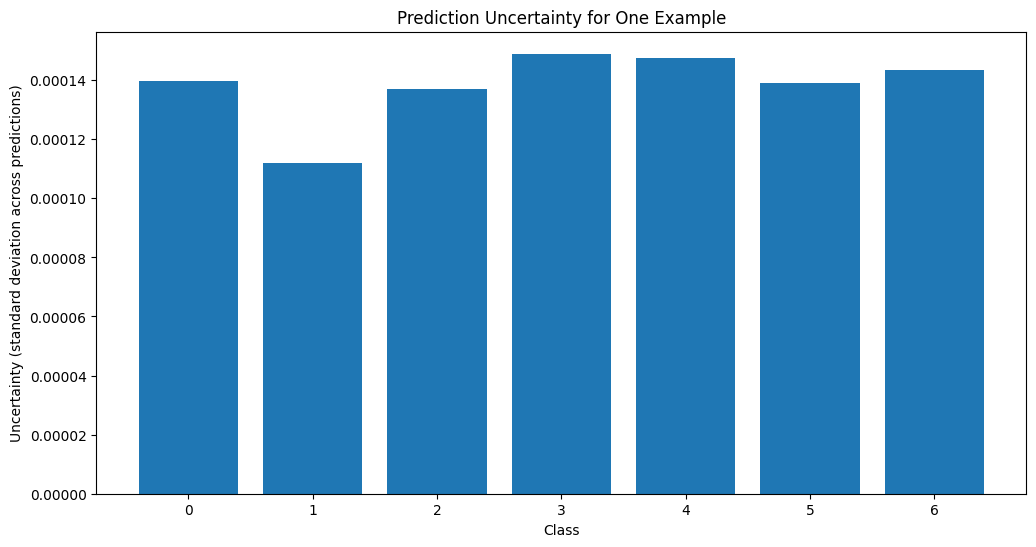

In [ ]:
# Monte Carlo Dropout for Uncertainty Estimation
def predict_with_uncertainty(model, X, n_iter=100):
    result = np.zeros((n_iter,) + (X.shape[0], model.output_shape[-1]))
    for i in range(n_iter):
        result[i] = model.predict(X, batch_size=32)
    prediction_means = np.mean(result, axis=0)
    prediction_uncertainty = np.std(result, axis=0)
    return prediction_means, prediction_uncertainty

# Use a subset of validation images for demonstration
subset_of_images = validation_images[:10]
predictions, uncertainties = predict_with_uncertainty(model, subset_of_images)

# Display results
print("Predictions Mean:\n", predictions)
print("Predictions Uncertainty:\n", uncertainties)

# Optionally visualize uncertainty
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(range(len(uncertainties[0])), uncertainties[0])
plt.title('Prediction Uncertainty for One Example')
plt.xlabel('Class')
plt.ylabel('Uncertainty (standard deviation across predictions)')
plt.show()

In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name)


0 input_2
1 conv1_pad
2 conv1_conv
3 conv1_bn
4 conv1_relu
5 pool1_pad
6 pool1_pool
7 conv2_block1_1_conv
8 conv2_block1_1_bn
9 conv2_block1_1_relu
10 conv2_block1_2_conv
11 conv2_block1_2_bn
12 conv2_block1_2_relu
13 conv2_block1_0_conv
14 conv2_block1_3_conv
15 conv2_block1_0_bn
16 conv2_block1_3_bn
17 conv2_block1_add
18 conv2_block1_out
19 conv2_block2_1_conv
20 conv2_block2_1_bn
21 conv2_block2_1_relu
22 conv2_block2_2_conv
23 conv2_block2_2_bn
24 conv2_block2_2_relu
25 conv2_block2_3_conv
26 conv2_block2_3_bn
27 conv2_block2_add
28 conv2_block2_out
29 conv2_block3_1_conv
30 conv2_block3_1_bn
31 conv2_block3_1_relu
32 conv2_block3_2_conv
33 conv2_block3_2_bn
34 conv2_block3_2_relu
35 conv2_block3_3_conv
36 conv2_block3_3_bn
37 conv2_block3_add
38 conv2_block3_out
39 conv3_block1_1_conv
40 conv3_block1_1_bn
41 conv3_block1_1_relu
42 conv3_block1_2_conv
43 conv3_block1_2_bn
44 conv3_block1_2_relu
45 conv3_block1_0_conv
46 conv3_block1_3_conv
47 conv3_block1_0_bn
48 conv3_block1_3_bn

SVM and Random Forest

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Function to extract features using a pre-trained model
def extract_features(model, images):
    features = model.predict(images)
    features_flattened = features.reshape(features.shape[0], -1)
    return features_flattened

# Feature extraction using the global_average_pooling2d_2 layer
feature_extractor = Model(inputs=model.input, outputs=model.get_layer('global_average_pooling2d').output)

# Use the feature extractor to process the training and validation data
train_features = feature_extractor.predict(train_images)
validation_features = feature_extractor.predict(validation_images)

# Flatten the features to 2D array as expected by SVM and Random Forest
train_features_flat = train_features.reshape((train_features.shape[0], -1))
validation_features_flat = validation_features.reshape((validation_features.shape[0], -1))

# Get the labels in the correct shape for traditional classifiers
train_labels_single = np.argmax(train_labels, axis=1)
validation_labels_single = np.argmax(validation_labels, axis=1)

# Train the SVM classifier
svm_classifier = SVC(kernel='linear', probability=True)
svm_classifier.fit(train_features_flat, train_labels_single)
svm_predictions = svm_classifier.predict(validation_features_flat)
svm_accuracy = accuracy_score(validation_labels_single, svm_predictions)
print("SVM Validation Accuracy:", svm_accuracy)

# Train the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(train_features_flat, train_labels_single)
rf_predictions = rf_classifier.predict(validation_features_flat)
rf_accuracy = accuracy_score(validation_labels_single, rf_predictions)
print("Random Forest Validation Accuracy:", rf_accuracy)


7/7 [==============================] - 1s 85ms/step
SVM Validation Accuracy: 0.6373056994818653
Random Forest Validation Accuracy: 0.6113989637305699


Random Forest Hyperparameters

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
import numpy as np

# Define a smaller parameter grid
param_grid = {
    'n_estimators': [100, 150],  # fewer options
    'max_depth': [None, 10],  # fewer options
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

# Initialize a Random Forest classifier
rf = RandomForestClassifier()

# Initialize RandomizedSearchCV with fewer iterations for faster results
random_search = RandomizedSearchCV(rf, param_grid, n_iter=5, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)

# Perform random search to find the best parameters
random_search.fit(train_features_flat, train_labels_single)

# Get the best estimator
best_rf = random_search.best_estimator_

# Train the Random Forest classifier with the best parameters
best_rf.fit(train_features_flat, train_labels_single)

# Predict and evaluate on the validation set
rf_predictions = best_rf.predict(validation_features_flat)
rf_accuracy = accuracy_score(validation_labels_single, rf_predictions)

print(f"Random Forest Validation Accuracy after Hyperparameter Tuning: {rf_accuracy:.4f}")
print(classification_report(validation_labels_single, rf_predictions))

# Optional: print best parameters
print("Best parameters:", random_search.best_params_)


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Random Forest Validation Accuracy after Hyperparameter Tuning: 0.6373
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        21
           1       0.64      1.00      0.78       123
           2       0.00      0.00      0.00        15
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00        22
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         3

    accuracy                           0.64       193
   macro avg       0.09      0.14      0.11       193
weighted avg       0.41      0.64      0.50       193

Best parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Model Evaluation - Cross Validation and Statistical Significance

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy import stats

# Define k-fold cross-validation configuration
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform k-fold cross-validation for SVM
svm_scores = cross_val_score(svm_classifier, train_features_flat, train_labels_single, cv=kfold, scoring='accuracy')
print("SVM Accuracy: %0.2f (+/- %0.2f)" % (svm_scores.mean(), svm_scores.std() * 2))

# Perform k-fold cross-validation for Random Forest
rf_scores = cross_val_score(rf_classifier, train_features_flat, train_labels_single, cv=kfold, scoring='accuracy')
print("Random Forest Accuracy: %0.2f (+/- %0.2f)" % (rf_scores.mean(), rf_scores.std() * 2))

# Perform paired t-test to see if the difference in performance is statistically significant
t_stat, p_value = stats.ttest_rel(svm_scores, rf_scores)
print("Paired t-test p-value:", p_value)

# Check if the difference in mean performance is statistically significant
if p_value < 0.05:
    print("The difference in performance between the SVM and Random Forest is statistically significant.")
else:
    print("No significant difference in performance between the SVM and Random Forest was found.")


SVM Accuracy: 0.68 (+/- 0.01)
Random Forest Accuracy: 0.66 (+/- 0.02)
Paired t-test p-value: 0.04016445173138062
The difference in performance between the SVM and Random Forest is statistically significant.


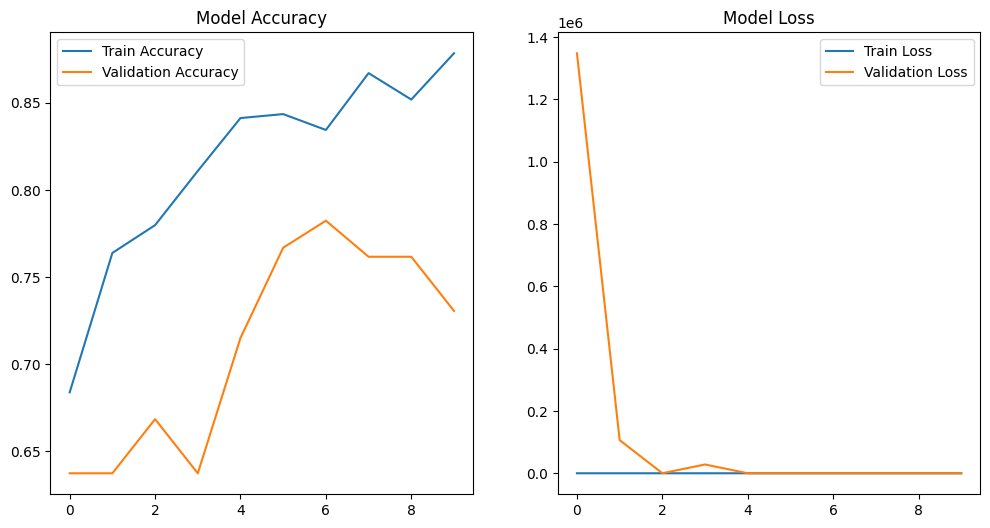

Best RF Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    # Visualization of training progress
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.legend()
    plt.show()

plot_training_history(history)

# Print best RF parameters
print("Best RF Parameters:", random_search.best_params_)


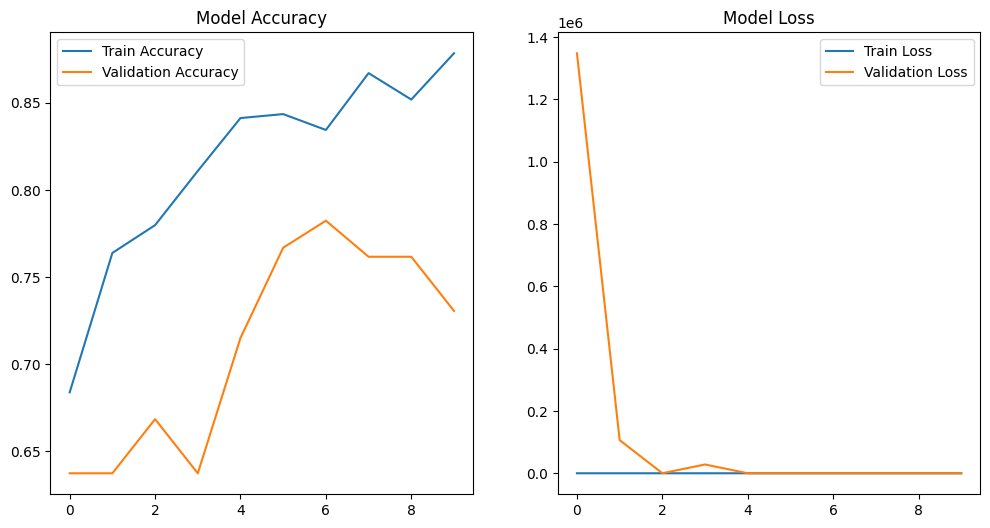

Best RF Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    # Visualization of training progress
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.legend()
    plt.show()

plot_training_history(history)

# Print best RF parameters
print("Best RF Parameters:", random_search.best_params_)


In [ ]:
import pandas as pd
import numpy as np
import cv2
import os

from google.colab import drive
drive.mount('/content/drive')

# Load the Labels from CSV Files
train_labels_path = '/content/drive/MyDrive/ISIC_Data/ISIC2018_Task3_Training_GroundTruth/ISIC2018_Task3_Training_GroundTruth/ISIC2018_Task3_Training_GroundTruth.csv'
train_labels_df = pd.read_csv(train_labels_path)

# Calculate basic statistics
class_counts = train_labels_df.iloc[:, 1:].sum().rename('count').reset_index()
class_counts.columns = ['Class', 'Count']
print("Class distribution in training data:\n", class_counts)

# Function to preprocess and load images
def load_and_preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    img = cv2.resize(img, (224, 224))  # Resize to match input requirements of the model
    img = img / 255.0  # Normalize pixel values to [0, 1]
    return img

# Load a subset of images and calculate pixel statistics
train_img_dir = '/content/drive/MyDrive/ISIC_Data/ISIC2018_Task3_Training_Input/ISIC2018_Task3_Training_Input'
sample_images = train_labels_df['image'][:100]  # Adjust slice for larger dataset
pixel_values = []

for img_name in sample_images:
    img_path = os.path.join(train_img_dir, img_name + '.jpg')
    if os.path.exists(img_path):
        img = load_and_preprocess_image(img_path)
        pixel_values.append(img.flatten())

pixel_values = np.array(pixel_values)
mean_pixels = np.mean(pixel_values, axis=0)
std_pixels = np.std(pixel_values, axis=0)

print("Mean pixel value:", mean_pixels)
print("Standard deviation of pixel values:", std_pixels)

Mounted at /content/drive
Class distribution in training data:
    Class   Count
0    MEL  1113.0
1     NV  6705.0
2    BCC   514.0
3  AKIEC   327.0
4    BKL  1099.0
5     DF   115.0
6   VASC   142.0
Mean pixel value: [0.73894118 0.51058824 0.54623529 ... 0.67760784 0.48482353 0.49827451]
Standard deviation of pixel values: [0.22016614 0.16724651 0.18317319 ... 0.22724554 0.17980694 0.18553688]


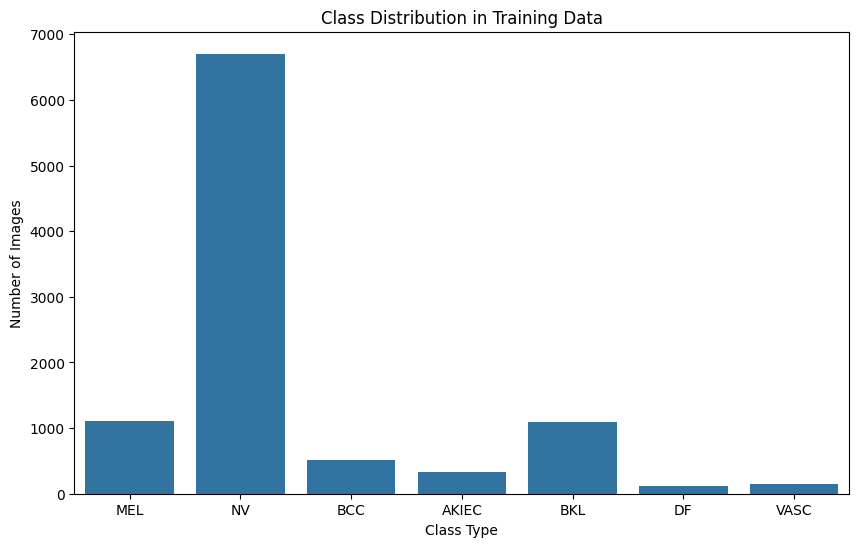

Mean pixel value: [0.74336471 0.51884706 0.55767843 ... 0.69657255 0.50032941 0.5152    ]
Standard deviation of pixel values: [0.22098137 0.16686375 0.18230177 ... 0.21713942 0.17324561 0.18275648]


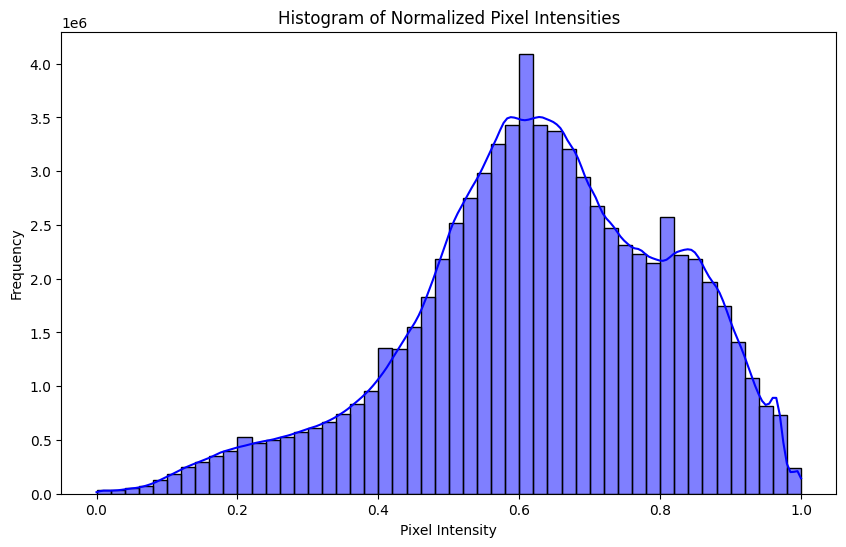

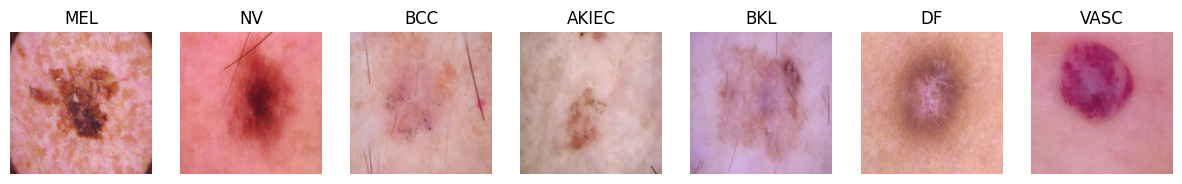

In [ ]:
import pandas as pd
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns

# # Load the Labels from CSV Files
# train_labels_path = '/content/drive/MyDrive/ISIC_Data/ISIC2018_Task3_Training_GroundTruth/ISIC2018_Task3_Training_GroundTruth.csv'
# train_labels_df = pd.read_csv(train_labels_path)

# Calculate basic statistics
class_counts = train_labels_df.iloc[:, 1:].sum().rename('count').reset_index()
class_counts.columns = ['Class', 'Count']

# Display class distribution as a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Count', data=class_counts)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Type')
plt.ylabel('Number of Images')
plt.show()

# Function to preprocess and load images
def load_and_preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    img = cv2.resize(img, (224, 224))  # Resize to match input requirements of the model
    img = img / 255.0  # Normalize pixel values to [0, 1]
    return img

# Load a subset of images and calculate pixel statistics
# train_img_dir = '/content/drive/MyDrive/ISIC_Data/ISIC2018_Task3_Training_Input/ISIC2018_Task3_Training_Input'
sample_images = train_labels_df['image'][:100]  # Adjust slice for larger dataset
pixel_values = []

for img_name in sample_images:
    img_path = os.path.join(train_img_dir, img_name + '.jpg')
    if os.path.exists(img_path):
        img = load_and_preprocess_image(img_path)
        pixel_values.append(img.flatten())

pixel_values = np.array(pixel_values)
mean_pixels = np.mean(pixel_values, axis=0)
std_pixels = np.std(pixel_values, axis=0)

print("Mean pixel value:", mean_pixels)
print("Standard deviation of pixel values:", std_pixels)

# Histogram of pixel intensity values
plt.figure(figsize=(10, 6))
sns.histplot(pixel_values.ravel(), bins=50, kde=True, color='blue')
plt.title('Histogram of Normalized Pixel Intensities')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

# Example images from each class
fig, axes = plt.subplots(1, len(class_counts), figsize=(15, 5))
for i, cls in enumerate(class_counts['Class']):
    cls_images = train_labels_df[train_labels_df[cls] == 1]['image'].values
    if len(cls_images) > 0:
        img_path = os.path.join(train_img_dir, cls_images[0] + '.jpg')
        if os.path.exists(img_path):
            img = load_and_preprocess_image(img_path)
            axes[i].imshow(img)
            axes[i].set_title(cls)
            axes[i].axis('off')
plt.show()

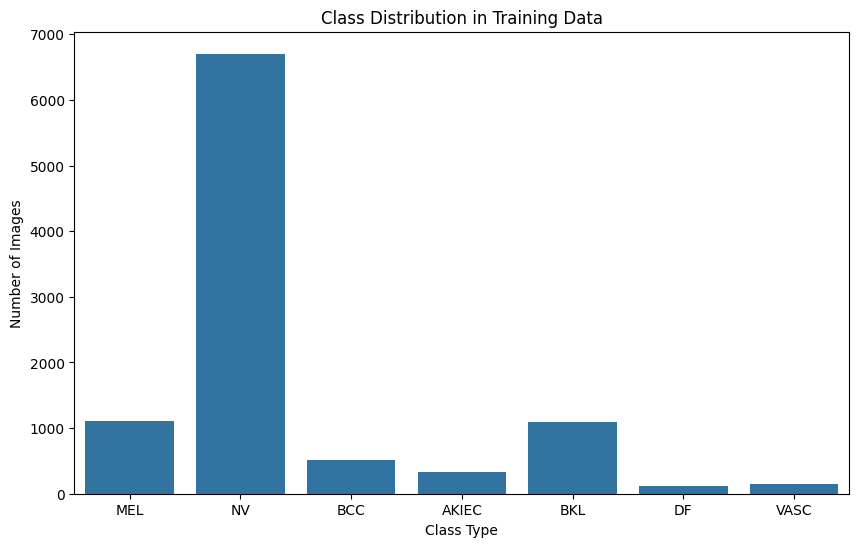

Mean pixel value: [0.7464986  0.55406162 0.61680672 ... 0.65434174 0.48823529 0.51484594]
Standard deviation of pixel values: [0.11816513 0.11202661 0.11546462 ... 0.15986522 0.14687196 0.1562483 ]


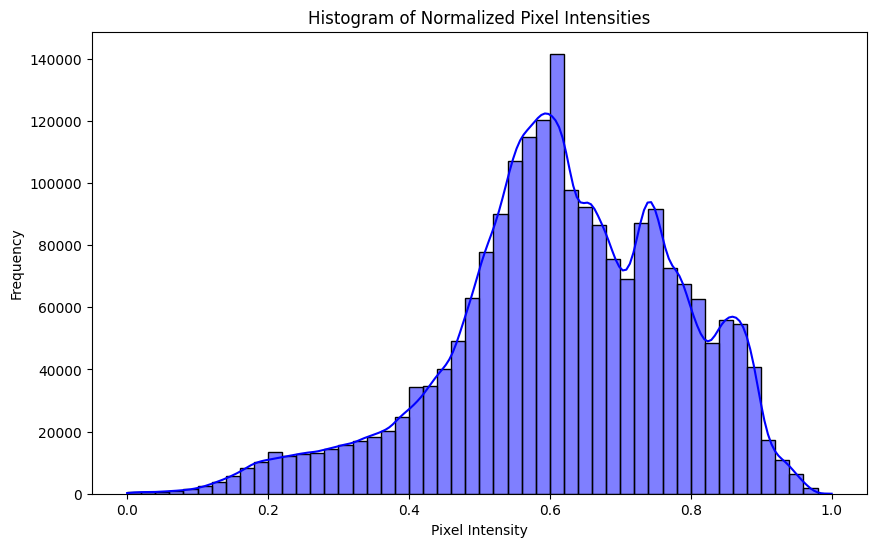

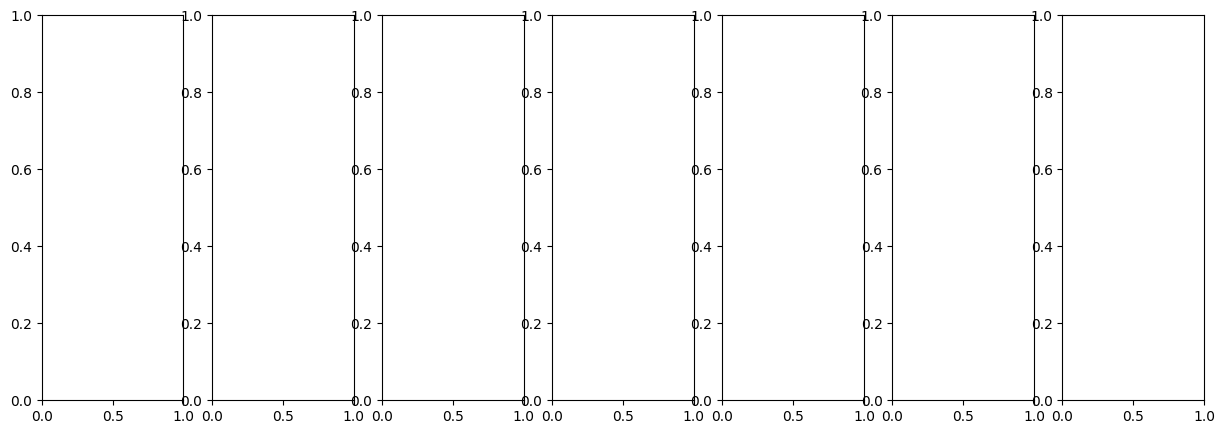

In [ ]:
import pandas as pd
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Labels from CSV Files
# train_labels_path = '/content/drive/MyDrive/ISIC_Data/ISIC2018_Task3_Training_GroundTruth/ISIC2018_Task3_Training_GroundTruth.csv'
# train_labels_df = pd.read_csv(train_labels_path)

# Calculate basic statistics
class_counts = train_labels_df.iloc[:, 1:].sum().rename('count').reset_index()
class_counts.columns = ['Class', 'Count']

# Display class distribution as a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Count', data=class_counts)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Type')
plt.ylabel('Number of Images')
plt.show()

# Function to preprocess and load images
def load_and_preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    img = cv2.resize(img, (224, 224))  # Resize to match input requirements of the model
    img = img / 255.0  # Normalize pixel values to [0, 1]
    return img

# Load a random subset of images and calculate pixel statistics
#train_img_dir = '/content/drive/MyDrive/ISIC_Data/ISIC2018_Task3_Training_Input/ISIC2018_Task3_Training_Input'
sample_images = train_labels_df['image'].sample(n=100, random_state=42)  # Randomly sample 100 images
pixel_values = []

for img_name in sample_images:
    img_path = os.path.join(train_img_dir, img_name + '.jpg')
    if os.path.exists(img_path):
        img = load_and_preprocess_image(img_path)
        pixel_values.append(img.flatten())

pixel_values = np.array(pixel_values)
mean_pixels = np.mean(pixel_values, axis=0)
std_pixels = np.std(pixel_values, axis=0)

print("Mean pixel value:", mean_pixels)
print("Standard deviation of pixel values:", std_pixels)

# Histogram of pixel intensity values
plt.figure(figsize=(10, 6))
sns.histplot(pixel_values.ravel(), bins=50, kde=True, color='blue')
plt.title('Histogram of Normalized Pixel Intensities')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

# Example images from each class
fig, axes = plt.subplots(1, len(class_counts), figsize=(15, 5))
for i, cls in enumerate(class_counts['Class']):
    cls_images = train_labels_df[train_labels_df[cls] == 1]['image'].sample(n=1, random_state=42).values
    if len(cls_images) > 0:
        img_path = os.path.join(train_img_dir, cls_images[0] + '.jpg')
        if os.path.exists(img_path):
            img = load_and_preprocess_image(img_path)
            axes[i].imshow(img)
            axes[i].set_title(cls)
            axes[i].axis('off')
plt.show()